<div align="center" style="display: inline-block; background: white; padding: 8px;">
  <img src="https://cdn.prod.website-files.com/633b44aa19e0eb425d7e8c7f/63724d646ecb4bd4cbdf7440_LOGO%20NUCLIO%20DIGITAL%20SCHOOL-01-01.png" alt="Nuclio Digital School" width="220">
</div>

# Clasificación y matriz de confusión

## Clasificación binaria

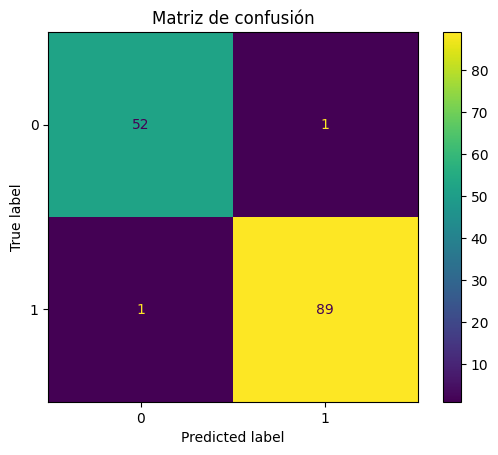

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143

Balanced accuracy: 0.9850104821802935


In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, recall_score, f1_score, balanced_accuracy_score
import matplotlib.pyplot as plt

X, y = load_breast_cancer(return_X_y=True) # devuelve (data, target) sin atributos como data, target, feature_names, descripción, etc

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de confusión")
plt.show()

print(classification_report(y_test, y_pred))
# print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))

## Clasificación multiclase

In [1]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

### 1. Descargar dataset de clasificación

Usaremos el dataset 'iris' para clasificación multiclase.

In [23]:
# Descargar dataset iris
iris = fetch_openml(name='iris', version=1, as_frame=True)

# Extraer características y target
X = iris.data
y = iris.target

print("Forma del dataset:", X.shape)
print("Clases:", np.unique(iris.target))
print("\nPrimeras 5 filas:")
print(iris.frame.head())

Forma del dataset: (150, 4)
Clases: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Primeras 5 filas:
   sepallength  sepalwidth  petallength  petalwidth        class
0          5.1         3.5          1.4         0.2  Iris-setosa
1          4.9         3.0          1.4         0.2  Iris-setosa
2          4.7         3.2          1.3         0.2  Iris-setosa
3          4.6         3.1          1.5         0.2  Iris-setosa
4          5.0         3.6          1.4         0.2  Iris-setosa


### 2. Exploración básica del dataset

In [3]:
# Información del dataset
print("Información del dataset:")
print(f"Número de muestras: {len(X)}")
print(f"Número de características: {X.shape[1]}")
print(f"Características: {list(X.columns)}")

# Distribución de clases
print("\nDistribución de clases:")
print(y.value_counts())

Información del dataset:
Número de muestras: 150
Número de características: 4
Características: ['sepallength', 'sepalwidth', 'petallength', 'petalwidth']

Distribución de clases:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


### 3. División de datos en train/test

In [4]:
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y  # Mantener proporciones de clases
)

print(f"Tamaño entrenamiento: {X_train.shape[0]}")
print(f"Tamaño test: {X_test.shape[0]}")

print("\nDistribución en entrenamiento:")
print(y_train.value_counts())
print("\nDistribución en prueba:")
print(y_test.value_counts())

Tamaño entrenamiento: 105
Tamaño test: 45

Distribución en entrenamiento:
class
Iris-setosa        35
Iris-versicolor    35
Iris-virginica     35
Name: count, dtype: int64

Distribución en prueba:
class
Iris-setosa        15
Iris-versicolor    15
Iris-virginica     15
Name: count, dtype: int64


### 4. Crear modelo básico de clasificación

In [5]:
# Crear y entrenar modelo de regresión logística
modelo = LogisticRegression(random_state=42, max_iter=1000)
modelo.fit(X_train, y_train)

# Realizar predicciones
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

# Calcular accuracy
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy en entrenamiento: {accuracy_train:.4f}")
print(f"Accuracy en prueba: {accuracy_test:.4f}")

Accuracy en entrenamiento: 0.9714
Accuracy en prueba: 0.9333


### 5. Generar matriz de confusión

In [25]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
print("Matriz de confusión:")
print(cm)

Matriz de confusión:
[[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]


### 6. Visualizar matriz de confusión

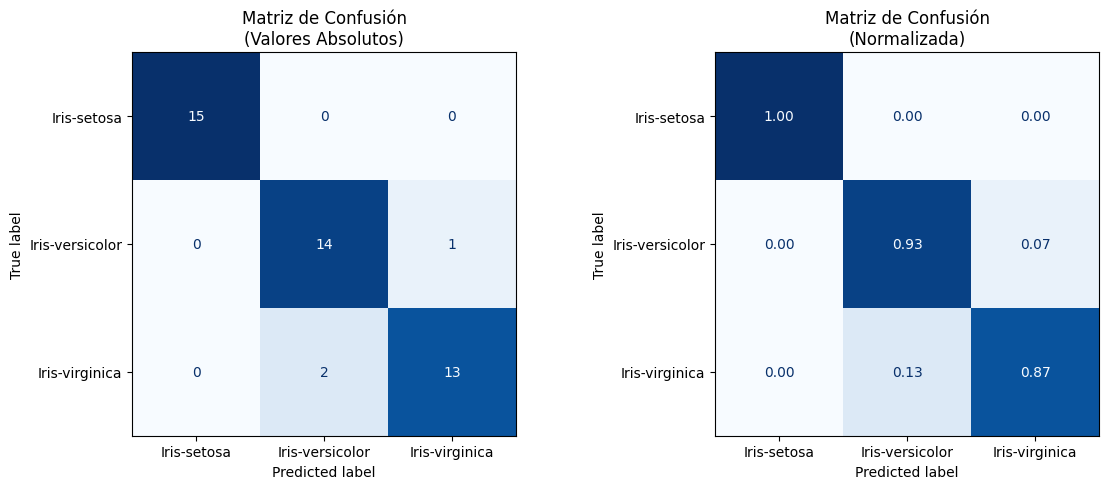

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Obtener las etiquetas presentes en y_test
labels = np.unique(y_test)

# Matriz de confusión con números absolutos
disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=labels
)
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión\n(Valores Absolutos)')

# Matriz de confusión normalizada
cm_normalized = confusion_matrix(y_test, y_pred_test, normalize='true')
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized, 
    display_labels=labels
)
disp2.plot(ax=axes[1], cmap='Blues', values_format='.2f', colorbar=False)
axes[1].set_title('Matriz de Confusión\n(Normalizada)')

plt.tight_layout()
plt.show()

### 7. Reporte de clasificación detallado

In [28]:
# Reporte de clasificación completo
print("Reporte de clasificación:")
print("=" * 56)
print(classification_report(
    y_test, 
    y_pred_test, 
    target_names=labels_presentes
))

Reporte de clasificación:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.88      0.93      0.90        15
 Iris-virginica       0.93      0.87      0.90        15

       accuracy                           0.93        45
      macro avg       0.93      0.93      0.93        45
   weighted avg       0.93      0.93      0.93        45



### 8. Análisis de errores

In [17]:
# Identificar predicciones incorrectas
errores = X_test[y_test != y_pred_test].copy()
errores['real'] = y_test[y_test != y_pred_test]
errores['predicho'] = y_pred_test[y_test != y_pred_test]

if len(errores) > 0:
    print(f"Número de errores: {len(errores)}")
    print("\nEjemplos mal clasificados:")
    print(errores)
else:
    print("¡Clasificación perfecta! No hay errores.")

Número de errores: 3

Ejemplos mal clasificados:
     sepallength  sepalwidth  petallength  petalwidth             real  \
133          6.3         2.8          5.1         1.5   Iris-virginica   
77           6.7         3.0          5.0         1.7  Iris-versicolor   
106          4.9         2.5          4.5         1.7   Iris-virginica   

            predicho  
133  Iris-versicolor  
77    Iris-virginica  
106  Iris-versicolor  


### Resumen observaciones clasificación multiclase

- **Dataset**: Iris con 3 clases (setosa, versicolor, virginica)
- **Modelo**: Regresión Logística
- **Evaluación**: Matriz de confusión y métricas de clasificación

La matriz de confusión nos permite:
- Ver qué clases se confunden entre sí
- Calcular métricas como precision, recall y F1-score
- Identificar patrones de error del modelo